In [97]:
from ollama import chat
from ollama import ChatResponse
import pandas as pd
import numpy as np
import seaborn
import plotly.express as px
from tqdm.auto import tqdm
from collections import defaultdict
import os
import json
from statsmodels.stats.contingency_tables import mcnemar

In [98]:
strategies = ["System1", "System2"]
alignment_techniques = ["dpo", "simpo"]
benchmarks = [
    "addsub",
    "aqua",
    "common",
    "gsm",
    "strategy",
    "single",
    "coin",
    "multi",
    "svamp",
    "letter",
]

type_of_questions = {
    "common": "Common Sense",
    "strategy": "Common Sense",
    "coin": "Symbolic",
    "letter": "Symbolic",
    # "object": "other",
    # all others, Arithmetic
    "addsub": "Arithmetic",
    "gsm": "Arithmetic",
    "single": "Arithmetic",
    "aqua": "Arithmetic",
    "svamp": "Arithmetic",
    "multi": "Arithmetic",
}

number_of_new_lines = {
    "addsub": 1,
    "aqua": 1,
    "common": 1,
    "gsm": 1,
    "strategy": 1,
    "single": 1,
    # "object": 4,
    "coin": 1,
    "multi": 1,
    "letter": 1,
    "svamp": 1,
}

In [99]:
alignment_technique_index = 0
alignment_technique = alignment_techniques[alignment_technique_index]

print("Alignment technique:", alignment_technique)

Alignment technique: dpo


In [100]:
all_datasets_df = None

for benchmark in benchmarks:

    file_name_system1 = os.path.join(
        "results",
        alignment_technique.upper(),
        strategies[0],
        f"{alignment_technique} - {benchmark}.csv",
    )
    file_name_system2 = os.path.join(
        "results",
        alignment_technique.upper(),
        strategies[1],
        f"{alignment_technique} - {benchmark}.csv",
    )

    sys1_data = pd.read_csv(file_name_system1)
    sys2_data = pd.read_csv(file_name_system2)

    # for columns pred_after and GT, if either is float, convert both to float
    # otherwise, convert both to string

    sys1_data = sys1_data.rename(
        columns={col: f"sys1_{col}" for col in sys1_data.columns}
    )
    sys2_data = sys2_data.rename(
        columns={col: f"sys2_{col}" for col in sys2_data.columns}
    )

    merged_data = pd.concat([sys1_data, sys2_data], axis=1)
    merged_data["benchmark"] = benchmark
    merged_data["ability"] = type_of_questions[benchmark]
    merged_data = merged_data.rename(
        columns={
            "sys1_pred_before": "sys1_second_answer",
            "sys2_pred_before": "sys2_second_answer",
        }
    )

    if all_datasets_df is None:
        all_datasets_df = merged_data
    else:
        all_datasets_df = pd.concat([all_datasets_df, merged_data], axis=0)

In [101]:
def extract_question(text):
    number_of_new_lines_in_benchmark = number_of_new_lines[benchmark]
    return "\n".join(text.split("\n")[:number_of_new_lines_in_benchmark])


def extract_first_answer(text):
    number_of_new_lines_in_benchmark = number_of_new_lines[benchmark]
    return "\n".join(text.split("\n")[number_of_new_lines_in_benchmark:])


def extract_final_answer_sys1(row):
    # append the first_answer which is sys1_first_answer to sys1_pred_before to get the final answer
    return f"{row['sys1_first_answer']}\n{row['sys1_second_answer']}"


def extract_final_answer_sys2(row):
    # append the first_answer which is sys1_first_answer to sys1_pred_before to get the final answer
    return f"{row['sys2_first_answer']}\n{row['sys2_second_answer']}"

In [102]:
all_datasets_df["sys1_question"] = all_datasets_df["sys1_input"].apply(extract_question)
all_datasets_df["sys1_first_answer"] = all_datasets_df["sys1_input"].apply(
    extract_first_answer
)
all_datasets_df["sys1_final_answer"] = all_datasets_df.apply(
    extract_final_answer_sys1, axis=1
)

all_datasets_df["sys2_question"] = all_datasets_df["sys2_input"].apply(extract_question)
all_datasets_df["sys2_first_answer"] = all_datasets_df["sys2_input"].apply(
    extract_first_answer
)
all_datasets_df["sys2_final_answer"] = all_datasets_df.apply(
    extract_final_answer_sys2, axis=1
)

# assert that all sys1_questions are equal to sys2_questions
assert (
    all_datasets_df["sys1_question"].values == all_datasets_df["sys2_question"].values
).all()

# do the same assertion for all the sys2 and sys1 GT
assert (all_datasets_df["sys1_GT"].values == all_datasets_df["sys2_GT"].values).all()
all_datasets_df.head(3)

,sys1_input,sys1_second_answer,sys1_pred_after,sys1_GT,sys2_input,sys2_second_answer,sys2_pred_after,sys2_GT,benchmark,ability,sys1_question,sys1_first_answer,sys1_final_answer,sys2_question,sys2_first_answer,sys2_final_answer
0,Joan found 70 seashells on the beach . she gav...,43,43.0,43.0,Joan found 70 seashells on the beach . she gav...,43,43.0,43.0,addsub,Arithmetic,Joan found 70 seashells on the beach . she gav...,Joan started with 70 seashells. She has 27 lef...,Joan started with 70 seashells. She has 27 lef...,Joan found 70 seashells on the beach . she gav...,Joan started with 70 seashells. She ended with...,Joan started with 70 seashells. She ended with...
1,There were 28 bales of hay in the barn . Tim s...,26,26.0,26.0,There were 28 bales of hay in the barn . Tim s...,26,26.0,26.0,addsub,Arithmetic,There were 28 bales of hay in the barn . Tim s...,There were originally 28 bales. After Tim stac...,There were originally 28 bales. After Tim stac...,There were 28 bales of hay in the barn . Tim s...,There were originally 28 bales of hay. After s...,There were originally 28 bales of hay. After s...
2,Mary is baking a cake . The recipe wants 8 cup...,6,6.0,6.0,Mary is baking a cake . The recipe wants 8 cup...,6,6.0,6.0,addsub,Arithmetic,Mary is baking a cake . The recipe wants 8 cup...,A simple one!\n\nThe recipe wants 8 cups of fl...,A simple one!\n\nThe recipe wants 8 cups of fl...,Mary is baking a cake . The recipe wants 8 cup...,A simple math problem!\n\nLet's break it down:...,A simple math problem!\n\nLet's break it down:...


In [103]:
def generate_few_shot_prompt(new_question, new_answer):
    prompt = f"""
Does the given answer directly answer the given question in a definitive way? ONLY RETURN YES OR NO IN A \\textbf{{}}. Definitive answers are clear and do not leave room for interpretation or ambiguity. If the answer tries to explore multiple perspectives or factors involved, it is not definitive and YOU HAVE TO RETURN NO.

Question: After hearing a company's first-quarter earnings, do you think it affects your outlook for the year?  
Answer: Yes, it’s challenging for me to reset my expectations, even if circumstances improve. 
\\textbf{{YES}}  
------------------  
Question: After hearing a company's first-quarter earnings, do you think it affects your outlook for the year?  
Answer: First-quarter earnings are informative but not sufficient for determining a company's annual outlook. 
\\textbf{{NO}}  
------------------  
Question: After hearing a product's starting price, does it change how much you are willing to pay?  
Answer: Yes, my idea of value hinges on the initial price I encounter. 
\\textbf{{YES}}  
------------------  
Question: After hearing a product's starting price, does it change how much you are willing to pay?  
Answer: In behavioral economics, the initial price of a product often acts as an "anchor," influencing our perceived value.
\\textbf{{NO}}  
------------------  
Question: Are accidents more likely during holiday travel?  
Answer: Holiday travel is often seen as more dangerous because we frequently hear about car crashes during this time.  
\\textbf{{YES}}  
------------------  
Question: Are accidents more likely during holiday travel?  
Answer: Several factors during holiday periods can elevate accident risks. 
\\textbf{{NO}}  
------------------  
Question: {new_question}  
Answer: {new_answer}  
\\textbf
"""
    return prompt

In [104]:
def get_few_shot_prediction(question, answer_first_sentence):
    content = generate_few_shot_prompt(question, answer_first_sentence)
    response: ChatResponse = chat(
        model="phi4",
        messages=[
            {
                "role": "user",
                "content": content,
            },
        ],
        options={"num_predict": 5, "temperature": 0.0},
    )
    return response["message"]["content"]

In [105]:
from nltk.tokenize import sent_tokenize


def extract_first_k_sentences(sent, k):
    # use nltk sentence tokenizer
    sentences = sent_tokenize(sent)
    return " ".join(sentences[:k])

In [106]:
data_point_index = 10
benchmark_index = 3
benchmark = benchmarks[benchmark_index]
strategy = "sys2"
datapoint = all_datasets_df[all_datasets_df["benchmark"] == benchmark].iloc[
    data_point_index
]
question = datapoint[f"{strategy}_question"]
answer = datapoint[f"{strategy}_final_answer"]
answer_first_three_sentences = extract_first_k_sentences(answer, 3)
print("Question:", question)
print("Strategy:", strategy)
print("Answer:", answer)
print("Answer first sentences:", answer_first_three_sentences)

Question: A new program had 60 downloads in the first month. The number of downloads in the second month was three times as many as the downloads in the first month, but then reduced by 30% in the third month. How many downloads did the program have total over the three months?
Strategy: sys2
Answer: The first month had 60 downloads. The second month had 3 times that, so 60 * 3 = 180 downloads. Then the third month reduced this by 30%. 30% of 180 is 0.3 * 180 = 54. So the third month had 180 - 54 = 126 downloads. The total number of downloads over the three months is 60 + 180 + 126 = 366. The answer is 366.
Therefore, the answer (arabic numerals) is
366
Answer first sentences: The first month had 60 downloads. The second month had 3 times that, so 60 * 3 = 180 downloads. Then the third month reduced this by 30%.


In [107]:
all_datasets_df["index"] = np.arange(len(all_datasets_df))

In [108]:
all_datasets_df["index"].shape, all_datasets_df["index"].nunique()

((8587,), 8587)

In [109]:
# random samples (200) from the dataset across benchmarks
sample_df = (
    all_datasets_df.groupby("benchmark")
    .apply(lambda x: x.sample(n=200, random_state=42))
    .reset_index(drop=True)
)

/var/folders/s6/_dcfmqnx4mxbhf22rbww8kwc0000gp/T/ipykernel_39091/3288077348.py:4: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [110]:
num_sentences = 3

if os.path.exists(f"results_with_direct_answer_annotations_{num_sentences}.csv"):
    all_datasets_df = pd.read_csv(
        f"results_with_direct_answer_annotations_{num_sentences}.csv"
    )
else:

    results = {}
    for i in tqdm(range(sample_df.shape[0])):
        data_point = sample_df.iloc[i]
        data_point_index = data_point["index"]
        question = data_point["sys1_question"]
        for strategy in ["sys1", "sys2"]:
            try:
                answer = data_point[f"{strategy}_final_answer"]
                first_k_sentences = extract_first_k_sentences(answer, num_sentences)
                response = get_few_shot_prediction(question, first_k_sentences)

                results[(data_point_index, strategy)] = response
            except:
                results[(data_point_index, strategy)] = "error"
                continue

    for (data_point_index, strategy), response in results.items():
        all_datasets_df.loc[
            all_datasets_df["index"] == data_point_index,
            f"{strategy}_few_shot_response",
        ] = response

    all_datasets_df.to_csv(
        f"results_with_direct_answer_annotations_{num_sentences}.csv",
        index=False,
    )

In [111]:
def extract_clean_direct_answer(direct_answer):
    direct_answer = str(direct_answer).lower()
    if "yes" in direct_answer:
        return "yes"
    elif "no" in direct_answer:
        return "no"
    else:
        return "error"

In [112]:
all_datasets_df["sys1_direct_answer"] = all_datasets_df["sys1_few_shot_response"].apply(
    extract_clean_direct_answer
)
all_datasets_df["sys2_direct_answer"] = all_datasets_df["sys2_few_shot_response"].apply(
    extract_clean_direct_answer
)
print(all_datasets_df["index"].nunique(), all_datasets_df.shape)

# rename the math ability to Arithmetic, and CS to Common Sense, and symbolic to Symbolic
all_datasets_df["ability"] = all_datasets_df["ability"].replace(
    {"math": "Arithmetic", "CS": "Common Sense", "symbolic": "Symbolic"}
)

# all_datasets_df = all_datasets_df[
#     all_datasets_df["ability"].isin(["math", "CS", "symbolic"])
# ]

8587 (8587, 21)


In [113]:
# among the samples with direct answers that are not nans, show how many of the sys1 and sys2 answers are yes and no using a subburns

strategies = []
indices = []
benchmarks = []
direct_answers = []
abilities = []

for index, row in all_datasets_df[
    ~all_datasets_df["sys1_direct_answer"].isna()
].iterrows():
    if row["sys1_direct_answer"] == "error" or row["sys2_direct_answer"] == "error":
        continue
    strategies.append("sys1")
    direct_answers.append(row["sys1_direct_answer"])
    strategies.append("sys2")
    direct_answers.append(row["sys2_direct_answer"])
    benchmarks.append(row["benchmark"])
    benchmarks.append(row["benchmark"])
    abilities.append(row["ability"])
    abilities.append(row["ability"])
    indices.append(row["index"])
    indices.append(row["index"])

data = pd.DataFrame(
    {
        "Strategy": strategies,
        "direct_answer_clean": direct_answers,
        "benchmark": benchmarks,
        "ability": abilities,
        "index": indices,
    }
)

In [114]:
# make a pie plot with the first layer being the Strategy and the second layer being how much of the direct_answer_clean for each strategy is yes or no
fig = px.sunburst(data, path=["Strategy", "direct_answer_clean"])
fig.show()

In [115]:
all_datasets_df_without_errors = all_datasets_df[
    (all_datasets_df["sys1_direct_answer"] != "error")
    & (all_datasets_df["sys2_direct_answer"] != "error")
]

sys1_yes_sys2_yes = all_datasets_df_without_errors[
    (all_datasets_df_without_errors["sys1_direct_answer"] == "yes")
    & (all_datasets_df_without_errors["sys2_direct_answer"] == "yes")
]

sys1_no_sys2_no = all_datasets_df_without_errors[
    (all_datasets_df_without_errors["sys1_direct_answer"] == "no")
    & (all_datasets_df_without_errors["sys2_direct_answer"] == "no")
]

sys1_yes_sys2_no = all_datasets_df_without_errors[
    (all_datasets_df_without_errors["sys1_direct_answer"] == "yes")
    & (all_datasets_df_without_errors["sys2_direct_answer"] == "no")
]

sys1_no_sys2_yes = all_datasets_df_without_errors[
    (all_datasets_df_without_errors["sys1_direct_answer"] == "no")
    & (all_datasets_df_without_errors["sys2_direct_answer"] == "yes")
]


table = np.array(
    [
        [len(sys1_yes_sys2_yes), len(sys1_yes_sys2_no)],
        [len(sys1_no_sys2_yes), len(sys1_no_sys2_no)],
    ]
)

result = mcnemar(table, exact=True, correction=True)
print(result)

pvalue      0.0015531302152038344
statistic   114.0


In [116]:
# make a pie plot with the first layer being the Strategy and the second layer being how much of the direct_answer_clean for each strategy is yes or no
fig = px.sunburst(data, path=["Strategy", "ability", "direct_answer_clean"])
# add the title that would explaion
fig.show()

ability: Arithmetic
sys1 yes ratio: 0.7023255813953488
sys2 yes ratio: 0.703875968992248
ability: Common Sense
sys1 yes ratio: 0.36910994764397903
sys2 yes ratio: 0.25392670157068065
ability: Symbolic
sys1 yes ratio: 0.23484848484848486
sys2 yes ratio: 0.19318181818181818


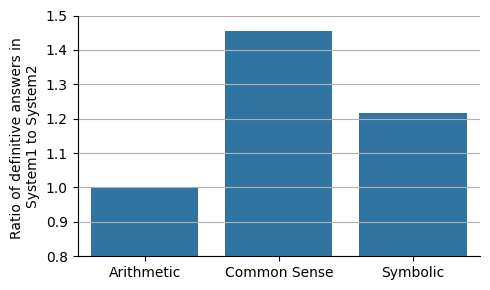

In [117]:
# in a bar plot, have two bars, one for sys1 which is the ratio of sys1's that are yes
# and another one for sys2 which is the ratio of sys2's that are yes
import seaborn as sns
import matplotlib.pyplot as plt

abilities = []
ratios = []

for ability in data["ability"].unique():
    ability_df = data[data["ability"] == ability]

    sys1_yes_ratio = (
        ability_df[
            (ability_df["Strategy"] == "sys1")
            & (ability_df["direct_answer_clean"] == "yes")
        ].shape[0]
        / ability_df[ability_df["Strategy"] == "sys1"].shape[0]
    )

    sys2_yes_ratio = (
        ability_df[
            (ability_df["Strategy"] == "sys2")
            & (ability_df["direct_answer_clean"] == "yes")
        ].shape[0]
        / ability_df[ability_df["Strategy"] == "sys2"].shape[0]
    )
    print("ability:", ability)
    print("sys1 yes ratio:", sys1_yes_ratio)
    print("sys2 yes ratio:", sys2_yes_ratio)

    sys1_ratio_to_sys2 = sys1_yes_ratio / sys2_yes_ratio
    abilities.append(ability)
    ratios.append(sys1_ratio_to_sys2)

plt.figure(figsize=(5, 3))
sns.barplot(x=abilities, y=ratios)
# make the whole thing more beautiful
sns.despine()
plt.grid(axis="y")
plt.ylabel("Ratio of definitive answers in \nSystem1 to System2")

plt.ylim(0.8, 1.5)

plt.tight_layout()

plt.savefig(
    "ratio_of_definitive_answers_in_first_3_sentences_per_ability.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [118]:
all_datasets_df_without_errors = all_datasets_df[
    (all_datasets_df["sys1_direct_answer"] != "error")
    & (all_datasets_df["sys2_direct_answer"] != "error")
]


for ability in all_datasets_df_without_errors["ability"].unique():
    print(f"\nAnalyzing ability: {ability}")

    ability_df = all_datasets_df_without_errors[
        all_datasets_df_without_errors["ability"] == ability
    ]

    sys1_yes_sys2_yes = ability_df[
        (ability_df["sys1_direct_answer"] == "yes")
        & (ability_df["sys2_direct_answer"] == "yes")
    ]

    sys1_no_sys2_no = ability_df[
        (ability_df["sys1_direct_answer"] == "no")
        & (ability_df["sys2_direct_answer"] == "no")
    ]

    sys1_yes_sys2_no = ability_df[
        (ability_df["sys1_direct_answer"] == "yes")
        & (ability_df["sys2_direct_answer"] == "no")
    ]

    sys1_no_sys2_yes = ability_df[
        (ability_df["sys1_direct_answer"] == "no")
        & (ability_df["sys2_direct_answer"] == "yes")
    ]

    table = np.array(
        [
            [len(sys1_yes_sys2_yes), len(sys1_yes_sys2_no)],
            [len(sys1_no_sys2_yes), len(sys1_no_sys2_no)],
        ]
    )

    result = mcnemar(table, exact=True, correction=True)
    print(result)
    print("N: ", table.sum())


Analyzing ability: Arithmetic
pvalue      1.0
statistic   65.0
N:  645

Analyzing ability: Common Sense
pvalue      4.935351419046992e-06
statistic   24.0
N:  382

Analyzing ability: Symbolic
pvalue      0.19252645776146274
statistic   24.0
N:  264
